In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


In [10]:
df = pd.read_csv("ENDES_Anemia_Hogar_2019_2024_LIMPIO.csv")

# Codificar variables categóricas a números
le_area = LabelEncoder()
le_depto = LabelEncoder()

df['Area_cod']  = le_area.fit_transform(df['Area_Residencia'].fillna('Desconocido'))
df['Depto_cod'] = le_depto.fit_transform(df['Departamento'].fillna('Desconocido'))

# Variable objetivo
le_target = LabelEncoder()
df['target'] = le_target.fit_transform(df['Nivel_Anemia'])

print("Clases:", list(le_target.classes_))
print("Total registros:", len(df))

Clases: ['Leve', 'Moderada', 'Severa', 'Sin anemia']
Total registros: 105027


In [20]:
#TRAIN
# Seleccionar las variables que usará el modelo
features = ['Edad_Meses', 'Peso_kg', 'Talla_cm',
            'Zscore_Talla_Edad', 'Zscore_Peso_Edad', 'Zscore_Peso_Talla', 'Zscore_IMC',
            'Altitud', 'Area_cod', 'Depto_cod']

# X son las variables de entrada, y es lo que queremos predecir
X = df[features].dropna()
y = df.loc[X.index, 'target_binario']

# Dividir en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (84021, 10)
Datos de prueba: (21006, 10)


In [21]:
#RANDOM FOREST
modelo = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [ ]:
# Ajustar umbral: en vez de 0.5 usamos 0.35
y_prob = modelo.predict_proba(X_test)[:, 1]
y_pred_ajustado = (y_prob >= 0.35).astype(int)

print("Con umbral ajustado (0.35):")
print("Accuracy:", round(accuracy_score(y_test, y_pred_ajustado), 4))
print("\nReporte completo:")
print(classification_report(y_test, y_pred_ajustado, target_names=['Sin anemia', 'Con anemia']))

Con umbral ajustado (0.35):
Accuracy: 0.6721

Reporte completo:
              precision    recall  f1-score   support

  Sin anemia       0.79      0.69      0.74     13911
  Con anemia       0.51      0.64      0.57      7095

    accuracy                           0.67     21006
   macro avg       0.65      0.66      0.65     21006
weighted avg       0.69      0.67      0.68     21006



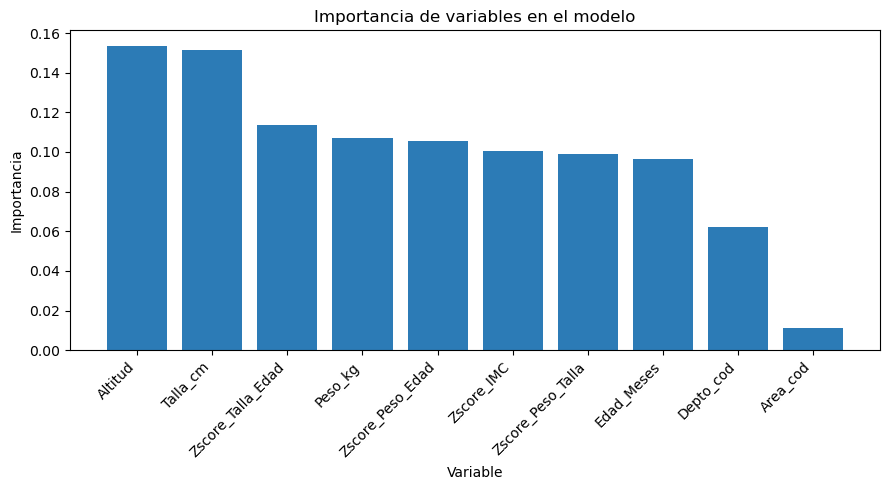

In [ ]:
# Importancia de cada variable en el modelo
importancias = pd.Series(modelo.feature_importances_, index=features)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(importancias.index, importancias.values, color='#2C7BB6')
plt.title('Importancia de variables en el modelo')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Función del agente inteligente
def agente_anemia(edad_meses, peso_kg, talla_cm, zscore_talla_edad,
                  zscore_peso_edad, zscore_peso_talla, zscore_imc,
                  altitud, area, departamento):

    # Codificar área y departamento
    area_cod  = le_area.transform([area])[0]
    depto_cod = le_depto.transform([departamento])[0]

    #  datos del niño
    datos = pd.DataFrame([[edad_meses, peso_kg, talla_cm, zscore_talla_edad,
                           zscore_peso_edad, zscore_peso_talla, zscore_imc,
                           altitud, area_cod, depto_cod]], columns=features)

    # Predecir probabilidad de anemia
    probabilidad = modelo.predict_proba(datos)[0][1]
    prediccion   = 'Con anemia' if probabilidad >= 0.35 else 'Sin anemia'

    # Recomendaciones
    print("=" * 45)
    print("   AGENTE DE DETECCIÓN DE ANEMIA INFANTIL")
    print("=" * 45)
    print(f"Resultado    : {prediccion}")
    print(f"Probabilidad : {probabilidad:.1%}")
    print("-" * 45)

    if prediccion == 'Con anemia':
        print("⚠️  RECOMENDACIONES:")
        print("  - Realizar medición de hemoglobina urgente")
        print("  - Derivar al centro de salud más cercano")
        print("  - Aumentar consumo de alimentos con hierro")
        print("    (sangrecita, hígado, lentejas, espinaca)")
        print("  - Evitar té o café junto a las comidas")
    else:
        print("✅  RECOMENDACIONES:")
        print("  - Continuar con controles de crecimiento")
        print("  - Mantener dieta variada y nutritiva")
        print("  - Próxima evaluación en 6 meses")

    print("=" * 45)

In [26]:
# Prueba del agente con un niño de ejemplo
agente_anemia(
    edad_meses       = 24,
    peso_kg          = 11.5,
    talla_cm         = 83.0,
    zscore_talla_edad= -1.2,
    zscore_peso_edad = -0.8,
    zscore_peso_talla= -0.3,
    zscore_imc       = -0.3,
    altitud          = 3500,
    area             = 'Rural',
    departamento     = 'Puno'
)

   AGENTE DE DETECCIÓN DE ANEMIA INFANTIL
Resultado    : Con anemia
Probabilidad : 58.0%
---------------------------------------------
⚠️  RECOMENDACIONES:
  - Realizar medición de hemoglobina urgente
  - Derivar al centro de salud más cercano
  - Aumentar consumo de alimentos con hierro
    (sangrecita, hígado, lentejas, espinaca)
  - Evitar té o café junto a las comidas
